# Predict the pedestal using ESCAPE for ARC baseline scenario

In [9]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve

from examples.device_prediction.helper_functions import calc_pressure_profile

In [10]:
# Import the ARC baseline scenario geqdsk if it does not currently exist
_ZENODO = 'https://zenodo.org/records/19498373/files'

def _fetch(filename):
    if not os.path.exists(filename):
        print(f'Downloading {filename} from Zenodo...', end=' ', flush=True)
        urllib.request.urlretrieve(f'{_ZENODO}/{filename}?download=1', filename)
        print('done.')

mhd_fp = 'geqdsk-ARCv3a'
_fetch(mhd_fp) # places geqdsk file in the current directory

Loaded ne: 79 points, psi_N in [0.0000, 1.0000], 3.19 -> 0.86 x10^20 m^-3
Loaded Te: 84 points, psi_N in [0.0000, 1.0000], 23.58 -> 0.20 keV


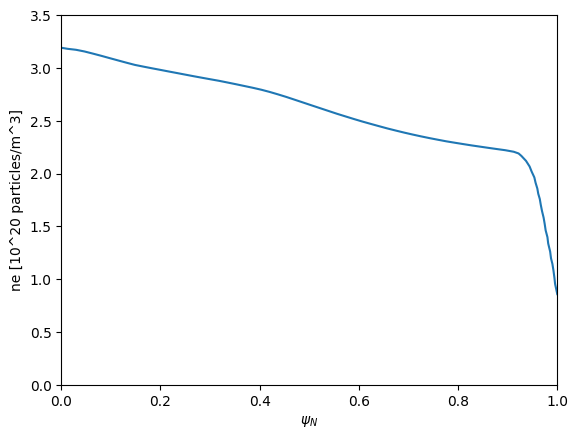

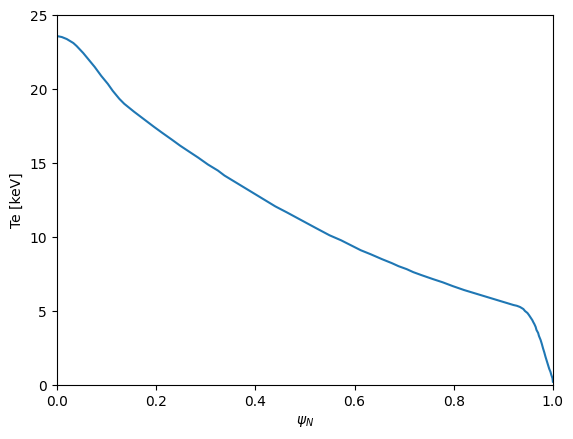

In [12]:
# Import reference profiles digitized from Leuthold et al. 2026 Fig. 1
# Both files are two-column Web Plot Digitizer exports on a psi_N abscissa:
#   ARC_ne.csv : psi_N, n_e [10^20 m^-3]
#   ARC_Te.csv : psi_N, T_e [keV]
#
# Fig. 1(a) truncates the density curves at both spines, so the panel shows
# n_e neither on axis nor at the separatrix. Both endpoint rows in ARC_ne.csv
# are linear extrapolations of the digitized curve:
#   psi_N = 0.0 -> 3.191   (head slope -0.7 per unit psi_N; the profile is flat
#                           here, and the figure's own centreline agrees to 0.1%)
#   psi_N = 1.0 -> 0.858   (tail slope -27 per unit psi_N; extrapolated across
#                           the 0.45% of psi_N hidden by the spine, so this one
#                           is uncertain at the ~0.05e20 level)
# The psi_N = 1.0 value sets the ne_x0 boundary condition - replace it if the
# true ARC separatrix density is known.

def load_digitized_profile(filepath):
    """Load psi_N and profile data from a Web Plot Digitizer CSV export.

    Parameters
    ----------
    filepath : str or Path
        Path to an ARC_ne.csv / ARC_Te.csv file.

    Returns
    -------
    psi_N : ndarray
        Normalized poloidal flux, sorted ascending and clipped to [0, 1].
    profile : ndarray
        ne in 10^20 m^-3 or Te in keV, depending on the file.
    """
    data = np.loadtxt(filepath, delimiter=',')
    psi_N, profile = data[:, 0], data[:, 1]

    # Digitization noise can push the outermost point just past the separatrix
    psi_N = np.clip(psi_N, 0.0, 1.0)

    order = np.argsort(psi_N, kind='stable')
    psi_N, profile = psi_N[order], profile[order]

    # Clipping can collide two points at psi_N = 1; keep the outermost sample
    unique = np.append(np.diff(psi_N) > 0, True)
    return psi_N[unique], profile[unique]


ne_fp = 'ARC_ne.csv'
Te_fp = 'ARC_Te.csv'

psi_N_ne, ne_ref = load_digitized_profile(ne_fp)   # 10^20 m^-3
psi_N_Te, Te_ref = load_digitized_profile(Te_fp)   # keV

print(f'Loaded ne: {len(psi_N_ne)} points, psi_N in [{psi_N_ne[0]:.4f}, {psi_N_ne[-1]:.4f}], '
      f'{ne_ref[0]:.2f} -> {ne_ref[-1]:.2f} x10^20 m^-3')
print(f'Loaded Te: {len(psi_N_Te)} points, psi_N in [{psi_N_Te[0]:.4f}, {psi_N_Te[-1]:.4f}], '
      f'{Te_ref[0]:.2f} -> {Te_ref[-1]:.2f} keV')

fig,ax = plt.subplots()
ax.plot(psi_N_ne, ne_ref, label='ne')
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel('ne [10^20 particles/m^3]')

fig1,ax1 = plt.subplots()
ax1.plot(psi_N_Te, Te_ref, label='Te')
ax1.set_xlabel(r'$\psi_N$')
ax1.set_ylabel('Te [keV]')

ax.set_xlim(0.0, 1)
ax.set_ylim(0, 3.5)
ax1.set_xlim(0.0, 1)
ax1.set_ylim(0, 25)


# kprof_loc = 'manual profs' reads the psi_N grids directly (no rho -> psi_N
# mapping) and expects n_e in m^-3 rather than 10^20 m^-3.
manual_profs = {
    'ne': ne_ref * 1e20,   # 10^20 m^-3 -> m^-3
    'Te': Te_ref,          # keV
    'psi_N_ne': psi_N_ne,
    'psi_N_Te': psi_N_Te,
}


In [13]:
# Parameters for ESCAPE #

# Output directory
out_dir = 'ARC_output_logs'
Path(out_dir).mkdir(parents=True, exist_ok=True)

verbose = True
verbose_sc = True

# Scan parameters
x_res = 50
free_params = {
    'alpha_crit': 10,
    'C_KBM': 0.1,
    'De_chie_etg': 1,
    'nFC_x0': 1e15,
    'ncx_x0_ratio': 17.8
}
epednn_model = 'EPED1' # 'EPED1' or 'EPED_SPARC'
eped_tol_max = 1e-5
eped_iter_max = 5
EPEDNN_core = 'previous T, stiched ne'
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

verbose_EPEDNNloop = True
verbose_sc = False

Setting up EPEDNN...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Base model built.
------------------------------------------------
ESCAPE Loop Iter 0
betan: [2.42033364]
Pedestal height: 0.12400267118830441 MPa, Pedestal width: 0.04391565159763431 (psi_N)
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 1
betan: [1.36090757]
Pedestal height: 0.10305388592715388 MPa, Pedestal width: 0.03658496423633095 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.33586470800720636


┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 2
betan: [1.30069822]
Pedestal height: 0.10260355618187278 MPa, Pedestal width: 0.03650295819070477 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.006611370487906217
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 3
betan: [1.3001946]
Pedestal height: 0.10144571569842109 MPa, Pedestal width: 0.03613412689293401 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.021388751991983045


┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 4
betan: [1.29438297]
Pedestal height: 0.10069131710215198 MPa, Pedestal width: 0.035899471502477985 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.01393048591763589
Setting up EPEDNN...


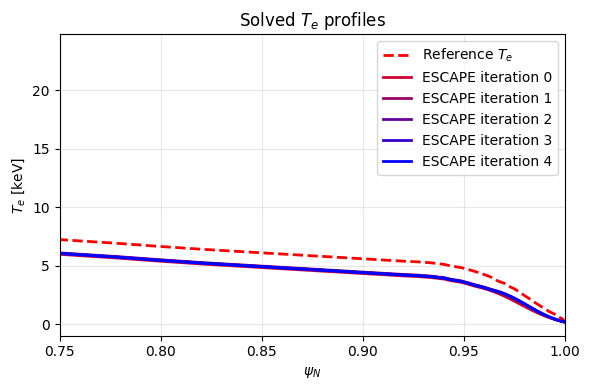

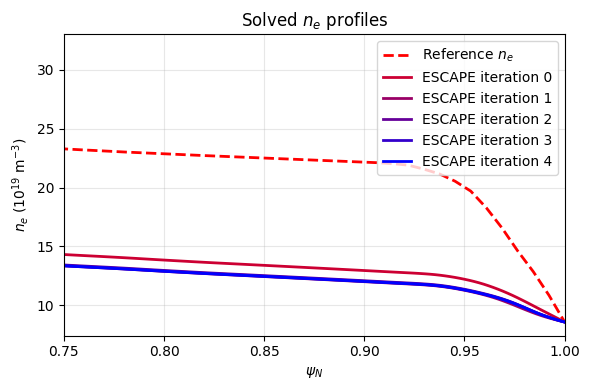

┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


In [14]:
# Model run
ped_wid, ped_h_out, sol = profiles_loop_solve(
    MHD_FP = mhd_fp,
    kprof_loc = 'manual profs',
    manual_profs = manual_profs,
    P_tot_e = ( 21.5 + 0.8 + 227 ) * 0.5 * 1e6, # table 4 of Hillesheim et al. 2026
    psi_N_inner = 0.75,
    out_dir = out_dir,
    species = 'D-T',
    # Z_i = Zeff,
    x_res = x_res,
    free_params = free_params,
    eped_tol_max = eped_tol_max,
    eped_iter_max = eped_iter_max,
    kbm_gate_eps = kbm_gate_eps,
    kbm_treatment = kbm_treatment,
    picard_gate_mode = picard_gate_mode,
    picard_max_it = picard_max_it,
    picard_rtol = picard_rtol,
    picard_relax = picard_relax,
    ig = 'manual',
    epednn_model = epednn_model,
    verbose = verbose_EPEDNNloop,
    verbose_sc = verbose_sc,
)

In [15]:
# Profile pressure at the EPEDNN-predicted pedestal top (psi_N = 1 - ped_wid)
psi_N_p, p_Pa, p_mode = calc_pressure_profile(manual_profs)
psi_ped_top = 1.0 - float(ped_wid)
p_at_ped_top = float(np.interp(psi_ped_top, psi_N_p, p_Pa))

print(f'Pressure formula: {p_mode}')
print(f'EPEDNN ped_top at psi_N = 1 - ped_wid = {psi_ped_top:.6f}')
print(f'Profile p(psi_ped_top) = {p_at_ped_top/1e3:.3f} kPa  ({p_at_ped_top/1e6:.4f} MPa)')
print(f'EPEDNN ped_h_out       = {float(ped_h_out)*1e3:.3f} kPa  ({float(ped_h_out):.4f} MPa)')
print(f'Accuracy of EPEDNN pedestal heightprediction: {100*(float(p_at_ped_top/1e6) - float(ped_h_out))/float(ped_h_out):.2f}%')


Pressure formula: 2*ne*Te
EPEDNN ped_top at psi_N = 1 - ped_wid = 0.964101
Profile p(psi_ped_top) = 226.233 kPa  (0.2262 MPa)
EPEDNN ped_h_out       = 100.691 kPa  (0.1007 MPa)
Accuracy of EPEDNN pedestal heightprediction: 124.68%


In [16]:
# Save model output
out_dict = {
    'mhd_fp': mhd_fp,
    'profiles': manual_profs,
    'ESCAPE_ped_h': ped_h_out,
    'ESCAPE_ped_wid': ped_wid,
    'experimental_ped_h': p_at_ped_top,
    'sol': sol
}
np.save(out_dir+'/ARC_pedestal_prediction.npy', out_dict)